In [3]:
import os, sys
from pathlib import Path

cur_dir = os.getcwd()
path = Path(cur_dir)
sys.path.insert(0, str(path.parent.absolute()))

import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np

from src.preprocess import preprocess_df
from src.network_connectivity import ConnectivityUnit
from src.analyze_cic_ids import nre_classification, flow_based_classification
from src.classification_tools import plot_roc_curves

from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from src.network_partitioning import apply_spec_clus

In [4]:
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Monday-WorkingHours.pcap_ISCX.csv' 
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Wednesday-workingHours.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Morning.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')

df = preprocess_df(df_cic, date_col=' Timestamp')
print(df.shape)


(529481, 85)


Conditioning number:  1.948437811336083e+38 
Determinant of F^T*F:  0.0


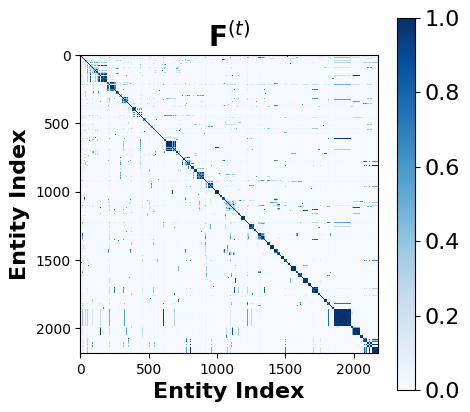

In [5]:
df = df.iloc[:50_000]
cu = ConnectivityUnit()
cu.read_flows(df, window_type= 'time', sync_window_size= 20, time_scale= 'sec')
cu.fit_connectivity_model(method = 'cov') # cov
cu.plot_f()

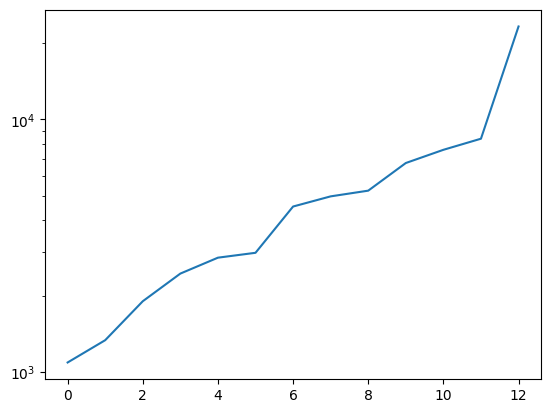

In [12]:
plt.semilogy(np.sort(cu.num_appearances))

In [8]:
import importlib, src
import src.network_connectivity

importlib.reload(src.network_connectivity)
from src.network_connectivity import*

In [13]:
cu.remove_infrequent(thr=1000)
entity_names = cu.names
len(entity_names)
with open('monday_freq_1000.pickle', 'wb') as handle:
    pickle.dump(entity_names, handle, protocol=pickle.HIGHEST_PROTOCOL)

13

In [6]:
victim_names = [ '192.168.10.3',
                 '192.168.10.50',
                 '192.168.10.51',
                 '192.168.10.19',
                 '192.168.10.17',
                 '192.168.10.16',
                 '192.168.10.12',
                 '192.168.10.9',
                 '192.168.10.5',
                 '192.168.10.8',
                 '192.168.10.14',
                 '192.168.10.15',
                 '192.168.10.25']

with open('victim_net.pickle', 'wb') as handle:
    pickle.dump(victim_names, handle, protocol=pickle.HIGHEST_PROTOCOL)
len(victim_names)

13

# Partitioning

In [6]:
with open(r'saves\monday_freq_1000.pickle', 'rb') as handle:
    entity_names = pickle.load(handle) 
len(entity_names)

991

In [20]:
with open(r'saves\victim_net.pickle', 'rb') as handle:
   entity_names = pickle.load(handle) 
len(entity_names)

13

Conditioning number:  7.965730775224758 
Determinant of F^T*F:  0.9024379743574009


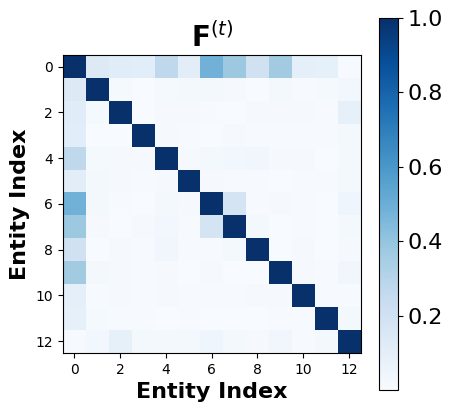

In [21]:
cu = ConnectivityUnit()
cu.read_flows(df, entity_names=entity_names, window_type= 'time', sync_window_size= 1.2, time_scale= 'sec')
cu.fit_connectivity_model(method = 'cov') # cov
cu.plot_f()

In [10]:
import importlib, src
import src.network_partitioning

importlib.reload(src.network_partitioning)
from src.network_partitioning import*

In [22]:
import src.network_connectivity, importlib

importlib.reload(src.network_connectivity)
from src.network_connectivity import*

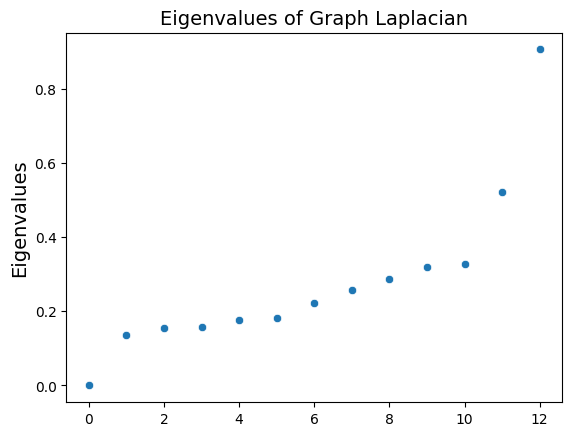

0.9665035843219003
[-1.13224990e-17  1.35905046e-01  1.53631588e-01  1.57092630e-01
  1.75273964e-01  1.82569706e-01  2.23638522e-01  2.56247095e-01
  2.88156367e-01  3.18078539e-01]


In [23]:
eigvals, err = get_eig_vals_err(cu.mat_f, cu.names)

print(err)
print(eigvals[:10])

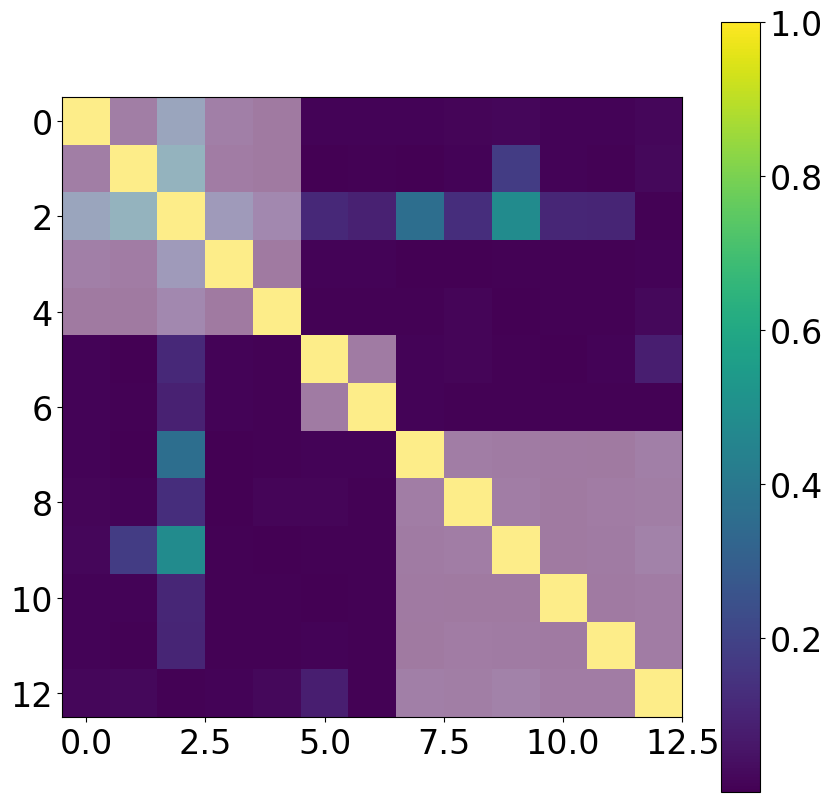

In [24]:
gr, new_labels, clusters = apply_spec_clus(cu.mat_f, cu.names, 3, fontsize = 24) # 117

In [33]:
sublist = apply_partitioning(cu, 3, plot_bool=False)

In [34]:
sublist[2].names

['192.168.10.50',
 '192.168.10.19',
 '192.168.10.16',
 '192.168.10.12',
 '192.168.10.8',
 '192.168.10.25']

In [26]:
new_labels

array([0, 0, 0, 0, 0, 1, 1, 2, 2, 2, 2, 2, 2])

23.076923076923077 % of the victim nodes are in one cluster for n= 21  clusters
Total size of the subnet:  803
23.076923076923077 % of the victim nodes are in one cluster for n= 31  clusters
Total size of the subnet:  413
15.384615384615385 % of the victim nodes are in one cluster for n= 41  clusters
Total size of the subnet:  274
15.384615384615385 % of the victim nodes are in one cluster for n= 51  clusters
Total size of the subnet:  317
7.6923076923076925 % of the victim nodes are in one cluster for n= 61  clusters
Total size of the subnet:  193
7.6923076923076925 % of the victim nodes are in one cluster for n= 71  clusters
Total size of the subnet:  173
7.6923076923076925 % of the victim nodes are in one cluster for n= 81  clusters
Total size of the subnet:  124
7.6923076923076925 % of the victim nodes are in one cluster for n= 91  clusters
Total size of the subnet:  122
7.6923076923076925 % of the victim nodes are in one cluster for n= 101  clusters
Total size of the subnet:  136


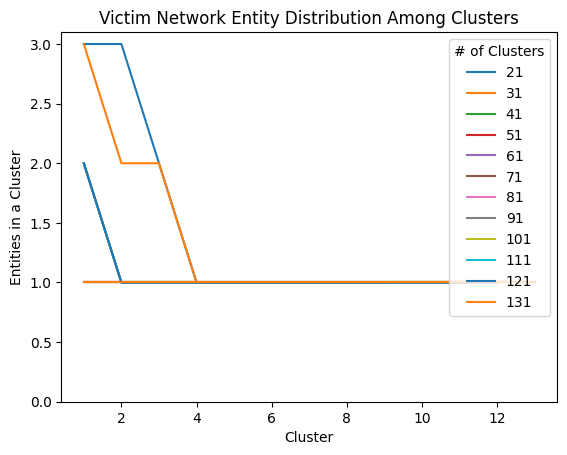

In [8]:
with open(r'saves\victim_net.pickle', 'rb') as handle:
    victim_network = pickle.load(handle) 

plt.rcParams.update({'font.size': 10})
ax = plt.subplot()
num_clusters = np.arange(21, 135, 10)
for i in num_clusters:
    ggr, new_labels, clusters = apply_spec_clus(cu.F, cu.names, i, plot_bool=False)
    clus_assign = get_clus_assign(victim_network, ggr, new_labels)
    _, inv_arr, counts = np.unique(list(clus_assign.values()), return_inverse=True, return_counts= True)
    _, clus_sizes = np.unique(new_labels, return_counts= True)
    sub_net_size = np.sum(clus_sizes[inv_arr])
    print( max(counts)/len(clus_assign) * 100, '% of the victim nodes are in one cluster for n=', i, ' clusters')
    print('Total size of the subnet: ', sub_net_size)
    
    plt.plot(np.arange(1, len(counts)+1).astype(int), np.sort(counts)[::-1], label=str(i))
    
plt.ylim([0, ax.get_ylim()[1]])
plt.title('Victim Network Entity Distribution Among Clusters')
plt.xlabel('Cluster')
plt.ylabel('Entities in a Cluster')
plt.legend(title='# of Clusters')
plt.show()

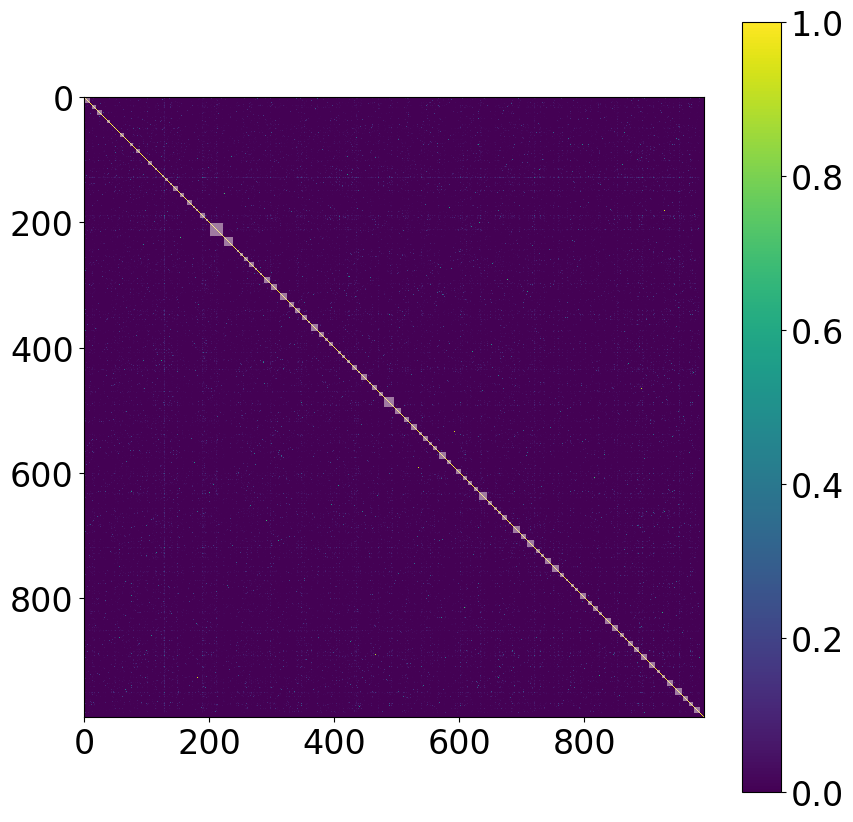

[  2  31  33  44  48  59  60  65  93 106 117 120]


(141,)

In [9]:
gr, new_labels, clusters = apply_spec_clus(cu.F, cu.names, 121, fontsize = 24, plot_bool=True) # 48
clus_assign = get_clus_assign(victim_network, gr, new_labels)
plt.rcParams.update({'font.size': 10})

target_clusters = np.unique(list(clus_assign.values()))
print(target_clusters)
idx = np.where(np.isin(new_labels, target_clusters))
np.array(list(gr.nodes))[idx].shape

Cluster 32
Conditioning number:  1.5423555573659935 
Determinant of F^T*F:  0.9990258184889945


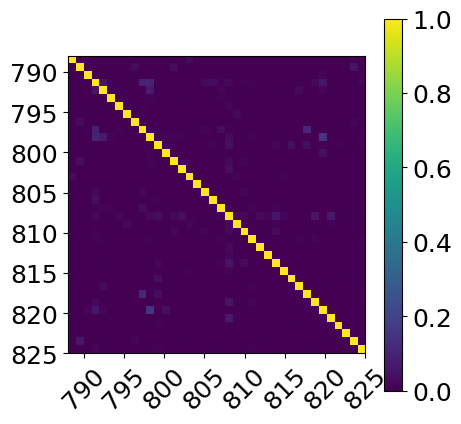

In [25]:
hr = get_graph_clus(gr, new_labels, clusters, 32, fontsize = 18) #8

In [10]:
calc_nodes = list(np.array(list(gr.nodes))[idx])
len(calc_nodes)

141

In [11]:
with open('saves//partitioned_nodes_141.pickle', 'wb') as handle: # sample_nodes.pickle
    pickle.dump(calc_nodes, handle, protocol=pickle.HIGHEST_PROTOCOL)


In [35]:
with open('saves//partitioned_nodes_377.pickle', 'rb') as handle:
    calc_nodes = pickle.load(handle) 

Conditioning number:  6.2631373693744194 
Determinant of F^T*F:  0.8338238077600261


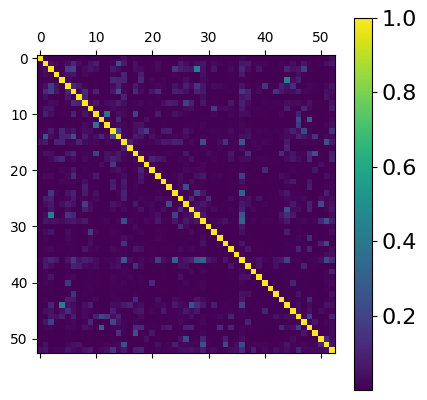

In [20]:
cu = ConnectivityUnit()
cu.read_flows(df, entity_names=calc_nodes, conn_param='Num Packets Rec', window_type= 'time', time_scale= 'sec')
cu.fit_graph_model(method = 'cov') # cov
cu.plot_f()
plt.show()

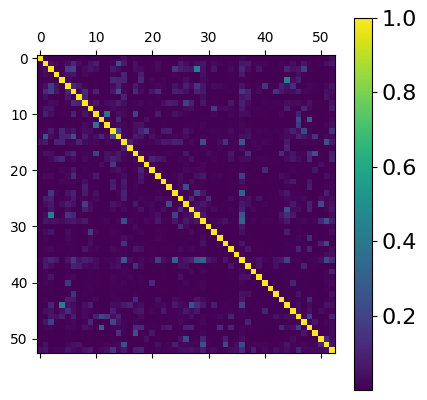

In [19]:
plt.show()

In [11]:
# Subgraphs
cond_dict = {}
nodes = np.array(list(gr.nodes))

for i, cluster in enumerate(clusters):
    ind = new_labels == cluster
    Hr = gr.subgraph(nodes[ind]).copy()
    A = nx.adjacency_matrix(Hr).todense()
    K = np.linalg.cond(A)
    d = np.linalg.det(A.T * A)
    print('Cluster '  + str(i) + '\nConditioning number: ', K, '\nDeterminant of F^T*F: ', d)
    cond_dict[cluster] = K

print(max(list(cond_dict.values())))

Cluster 0
Conditioning number:  1.1858079016188734 
Determinant of F^T*F:  0.9999509768996137
Cluster 1
Conditioning number:  1.0294947658530602 
Determinant of F^T*F:  0.9999999603357204
Cluster 2
Conditioning number:  1.1944283365259754 
Determinant of F^T*F:  0.9999504530706593
Cluster 3
Conditioning number:  1.3851247573190386 
Determinant of F^T*F:  0.9995373296610679
Cluster 4
Conditioning number:  1.187243119255009 
Determinant of F^T*F:  0.9999585950942437
Cluster 5
Conditioning number:  1.1695734942722704 
Determinant of F^T*F:  0.9999773837267613
Cluster 6
Conditioning number:  1.0050491612881451 
Determinant of F^T*F:  0.9999999999597861
Cluster 7
Conditioning number:  1.3485043225054048 
Determinant of F^T*F:  0.999732178800987
Cluster 8
Conditioning number:  1.0212322164520042 
Determinant of F^T*F:  0.9999999953208559
Cluster 9
Conditioning number:  1.372162249530943 
Determinant of F^T*F:  0.9997058902627208
Cluster 10
Conditioning number:  1.0136789643963764 
Determinan

Cluster 113
Conditioning number:  1.053100523837758 
Determinant of F^T*F:  0.9999997153098039
Cluster 114
Conditioning number:  2.024953411176656 
Determinant of F^T*F:  0.9868208454911809
Cluster 115
Conditioning number:  1.0315010585581517 
Determinant of F^T*F:  0.9999999772050826
Cluster 116
Conditioning number:  1.0123571203729012 
Determinant of F^T*F:  0.999999999434928
Cluster 117
Conditioning number:  1.014703420437529 
Determinant of F^T*F:  0.9999999990333063
Cluster 118
Conditioning number:  1.0542824552572099 
Determinant of F^T*F:  0.9999998317315469
Cluster 119
Conditioning number:  2.0729251085310247 
Determinant of F^T*F:  0.987414722614093
Cluster 120
Conditioning number:  1.0 
Determinant of F^T*F:  1.0
Cluster 121
Conditioning number:  1.0046886148748575 
Determinant of F^T*F:  0.999999999970078
Cluster 122
Conditioning number:  1.58547965659224 
Determinant of F^T*F:  0.9983250914873222
Cluster 123
Conditioning number:  1.0195170634641955 
Determinant of F^T*F:  0